# Initiation

In [1]:
'''
Setup & Dependencies

This notebook assumes the following Python packages are installed:
- pandas
- numpy
- matplotlib
- seaborn
- torch
- transformers

**Before running, install dependencies with:** 
pip install -r requirements.txt
**in the terminal.**
 '''

# --------------------------------------
# Standard Library Imports
# --------------------------------------~
import os  # For operating system dependent functionality

# --------------------------------------
# Third-party Library Imports
# --------------------------------------
import pandas as pd      # Data analysis and manipulation
import numpy as np       # Numerical operations
import matplotlib.pyplot as plt   # Data visualization
import seaborn as sns    # Statistical data visualization

# Libraries for deep learning and NLP (used later in notebook)
import torch             # PyTorch, for machine learning models
from transformers import AutoTokenizer, AutoModel  # Transformer models from HuggingFace, here we will use them for NLP tasks
from torch.utils.data import DataLoader, Dataset # Data loading utilities

# --------------------------------------
# Set up matplotlib for inline display
# --------------------------------------
%matplotlib inline

C:\Users\97109\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Move all things to GPU if applicable

In [2]:
# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Import Training Data

## Data from the original contest

In [3]:
df_train = pd.read_csv("train.csv")
df_train.columns

Index(['id', 'url_legal', 'license', 'excerpt', 'target', 'standard_error'], dtype='object')

Drop url, licese, and the training results

In [4]:
# URL and license are mostly empty we can intuitively know they won't have any siginificance
# We want to focus on the texts only

df_train = df_train.drop(['url_legal', 'license'], axis=1)
df_train.head()

,id,excerpt,target,standard_error
0,c12129c31,When the young people returned to the ballroom...,-0.340259,0.464009
1,85aa80a4c,"All through dinner time, Mrs. Fayre was somewh...",-0.315372,0.480805
2,b69ac6792,"As Roger had predicted, the snow departed as q...",-0.580118,0.476676
3,dd1000b26,And outside before the palace a great garden w...,-1.054013,0.450007
4,37c1b32fb,Once upon a time there were Three Bears who li...,0.247197,0.510845


## Dataset from CLEAR

In [5]:
# Read
CLEAR_df = pd.read_csv('CLEAR.csv')
CLEAR_df.columns

Index(['ID', 'Last Changed', 'Author', 'Title', 'Anthology', 'URL', 'Source',
       'Pub Year', 'Category', 'Location', 'License', 'MPAA\nMax',
       'MPAA \n#Max', 'MPAA\n#Avg', 'Excerpt', 'Google\nWC', 'Joon\nWC v1',
       'British WC', 'British Words', 'Sentence\nCount v1',
       'Sentence\nCount v2', 'Paragraphs', 'BT Easiness', 'BT s.e.',
       'Flesch-Reading-Ease', 'Flesch-Kincaid-Grade-Level',
       'Automated Readability Index', 'SMOG Readability',
       'New Dale-Chall Readability Formula', 'CAREC', 'CAREC_M', 'CARES',
       'CML2RI', 'firstPlace_pred', 'secondPlace_pred', 'thirdPlace_pred',
       'fourthPlace_pred', 'fifthPlace_pred', 'sixthPlace_pred',
       'Kaggle split'],
      dtype='object')

In [6]:
# Drop columns and store the result columns seperately
CLEAR_df = CLEAR_df.rename(columns={'ID': 'id', 'Excerpt': 'excerpt', 'BT Easiness': 'target', 'BT s.e.': 'standard_error'})
CLEAR_df.tail()

,id,Last Changed,Author,Title,Anthology,URL,Source,Pub Year,Category,Location,...,CAREC_M,CARES,CML2RI,firstPlace_pred,secondPlace_pred,thirdPlace_pred,fourthPlace_pred,fifthPlace_pred,sixthPlace_pred,Kaggle split
4721,8029.0,NaN,wikijunior,Bugs/Black Widow,Wikijunior\n,https://en.wikibooks.org/wiki/Wikijunior:Bugs/...,wikibooks,2020.0,Info,start,...,0.08300,0.486970,22.731214,0.162251,0.106933,-0.044770,0.016760,-0.043617,-0.079214,Test
4722,8030.0,NaN,wikijunior,Solids,Wikijunior\n,https://en.wikibooks.org/wiki/Geometry_for_Ele...,wikibooks,2014.0,Info,start,...,0.19583,0.381914,16.386932,-0.680378,-0.451011,-0.446233,-0.335672,-0.487118,-0.422290,Train
4723,8031.0,NaN,wikijunior,Anials,Wikijunior\n,https://en.wikibooks.org/wiki/Wikijunior:Biolo...,wikibooks,2018.0,Info,start,...,0.20880,0.495853,14.830202,0.357267,0.330677,0.230611,0.289018,0.382340,0.214723,Train
4724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Extract the ids and texts

In [7]:
CLEAR_df = CLEAR_df[['id', 'excerpt', 'target', 'standard_error']]
CLEAR_df.head()

,id,excerpt,target,standard_error
0,400.0,When the young people returned to the ballroom...,-0.340259,0.464009
1,401.0,"All through dinner time, Mrs. Fayre was somewh...",-0.315372,0.480805
2,402.0,"As Roger had predicted, the snow departed as q...",-0.580118,0.476676
3,403.0,Mr. Grimes was to come up next morning to Sir ...,-1.785965,0.526599
4,404.0,And outside before the palace a great garden w...,-1.054013,0.450007


# Concactenate datasets

## Merge datasets

In [8]:
concat_df_list = [df_train, CLEAR_df]

# Concatenate along rows and reset index
consolidated_df = pd.concat(concat_df_list, axis=0, ignore_index=True)

# Convert the 'id' column to string
consolidated_df['id'] = consolidated_df['id'].astype(str)

# Drop none types
consolidated_df = consolidated_df.dropna()
consolidated_df.isna().sum()

id                0
excerpt           0
target            0
standard_error    0
dtype: int64

In [9]:
# Drop duplicates
consolidated_df = consolidated_df.drop_duplicates()
consolidated_df.duplicated().sum()

0

In [10]:
consolidated_df.tail()

,id,excerpt,target,standard_error
7553,8027.0,The name Monarch means “king”. An adult Monarc...,0.423388,0.511439
7554,8028.0,"Walking Sticks are long, thin, and slow-moving...",-0.614142,0.475506
7555,8029.0,A Black Widow is a shiny black spider. It has ...,0.310336,0.508939
7556,8030.0,Solids are shapes that you can actually touch....,-0.215279,0.514128
7557,8031.0,Animals are made of many cells. They eat thing...,0.300779,0.512379


Save results

In [11]:
consolidated_df_results = consolidated_df[['target', 'standard_error']].copy()
consolidated_df_results.tail()

,target,standard_error
7553,0.423388,0.511439
7554,-0.614142,0.475506
7555,0.310336,0.508939
7556,-0.215279,0.514128
7557,0.300779,0.512379


Drop results columns

In [12]:
consolidated_df = consolidated_df.drop(['target', 'standard_error'], axis = 1)
consolidated_df.tail()

,id,excerpt
7553,8027.0,The name Monarch means “king”. An adult Monarc...
7554,8028.0,"Walking Sticks are long, thin, and slow-moving..."
7555,8029.0,A Black Widow is a shiny black spider. It has ...
7556,8030.0,Solids are shapes that you can actually touch....
7557,8031.0,Animals are made of many cells. They eat thing...


# General analysis of the data

In [13]:
text_length = consolidated_df['excerpt'].apply(lambda x: len(x.split(' ')))
print(f'--- Distribution of the Total Data Text Length ---\n')
print(text_length.describe())

--- Distribution of the Total Data Text Length ---

count    7558.000000
mean      171.840963
std        16.992603
min       125.000000
25%       158.000000
50%       173.000000
75%       186.000000
max       205.000000
Name: excerpt, dtype: float64


Plot of the distribution

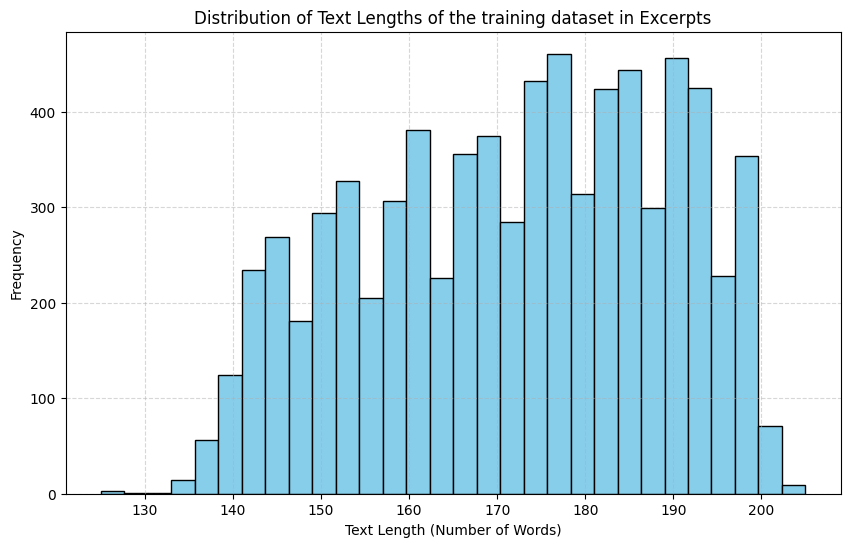

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(text_length, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Text Lengths of the training dataset in Excerpts')
plt.xlabel('Text Length (Number of Words)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Since the target datasets have a similar distribution and are both calculated using Bradley–Terry ease of readability score, we can directly concactenate them together.

# Import Testing Data

In [15]:
df_test = pd.read_csv("test.csv")
df_test.columns

Index(['id', 'url_legal', 'license', 'excerpt'], dtype='object')

Drop url and license columns

In [16]:
# Same as for the training dataset drop the insignificant columns

df_test = df_test.drop(['url_legal', 'license'], axis = 1)
df_test.head()

,id,excerpt
0,c0f722661,My hope lay in Jack's promise that he would ke...
1,f0953f0a5,Dotty continued to go to Mrs. Gray's every nig...
2,0df072751,It was a bright and cheerful scene that greete...
3,04caf4e0c,Cell division is the process by which a parent...
4,0e63f8bea,Debugging is the process of finding and resolv...


Analysis and plot of the data

In [17]:
text_length_test = df_test['excerpt'].apply(lambda x: len(x.split(' ')))
print(f'--- Distribution of the Total Data Text Length ---\n')
print(text_length_test.describe())

--- Distribution of the Total Data Text Length ---

count      7.000000
mean     164.142857
std       13.094892
min      147.000000
25%      154.500000
50%      167.000000
75%      173.500000
max      179.000000
Name: excerpt, dtype: float64


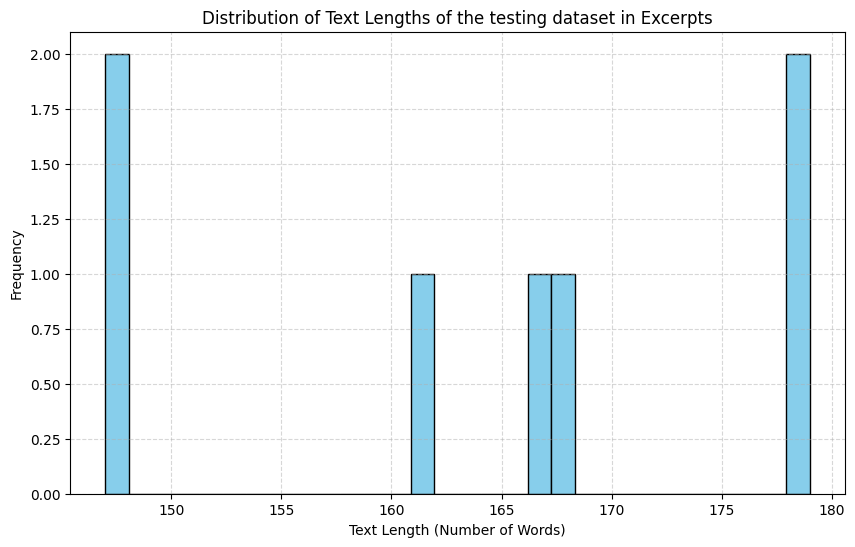

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(text_length_test, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Text Lengths of the testing dataset in Excerpts')
plt.xlabel('Text Length (Number of Words)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Data Preprocessing & Feature Engineering

In [20]:
# Text cleaning: Remove all puncuations and special characters
import re

def clean_for_reading_difficulty(text):
    if isinstance(text, str):
        # Keep basic punctuation: . , ? ! ' "
        text = re.sub(r'[^A-Za-z0-9\s\.\,\?\!\'\"]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
    return text

for col in consolidated_df.select_dtypes(include=['object', 'string']).columns:
    consolidated_df[col] = consolidated_df[col].apply(clean_for_reading_difficulty)
# Show one random cleaned excerpt
print(consolidated_df['excerpt'].sample(1).values[0])


An eclipse is an astronomical event. It is a process that develops slowly across time. The eclipse is when one object in the sky moves into the shadow of another such object. When an eclipse happens within a system of stars, like the Solar System, it makes a type of syzygy. This means that three or more objects in the sky are lined up in a straight line in the same gravitational system. The term eclipse is most often used to describe a solar eclipse, when the Moon's shadow crosses the Earth's surface, or a lunar eclipse, when the Moon moves into the shadow of Earth. No solar eclipse can last longer than 7 minutes and 58 seconds because of the speed at which the Earth and Moon move. When the Sun is not involved, the event is called occultation.


## Text tokenization

In [21]:
# Load a tokenizer — you can change the model to others like "roberta-base"
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# Tokenize the entire 'excerpt' column
tokenized = tokenizer(
    consolidated_df["excerpt"].tolist(),     # Convert to list of strings
    padding=True,                            # Pad to longest sequence
    truncation=True,                         # Truncate if too long
    return_tensors="pt",                     # Return PyTorch tensors
    return_attention_mask=True               # Include attention mask
)

print(tokenized)

{'input_ids': tensor([[  101,  2043,  1996,  ...,     0,     0,     0],
        [  101,  2035,  2083,  ...,     0,     0,     0],
        [  101,  2004,  5074,  ...,     0,     0,     0],
        ...,
        [  101,  1037,  2304,  ...,     0,     0,     0],
        [  101, 26778,  2024,  ...,     0,     0,     0],
        [  101,  4176,  2024,  ...,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])}


## Insert masks

In [22]:
import torch
import random

def apply_masking(input_ids, tokenizer, mask_prob=0.15):
    """
    Applies BERT-style random masking to tokenized input_ids.
    """
    labels = input_ids.clone()
    # Create a mask for tokens to be masked
    rand = torch.rand(input_ids.shape)
    mask_arr = (rand < mask_prob) & \
           (input_ids != tokenizer.cls_token_id) & \
           (input_ids != tokenizer.sep_token_id) & \
           (input_ids != tokenizer.pad_token_id)
    # Ensure at least one token is masked

    # Make a copy of input_ids to modify
    input_ids_masked = input_ids.clone()

    # 80% of the time, replace with [MASK]
    mask_indices = torch.where(mask_arr)
    for i in range(mask_indices[0].size(0)):
        row, col = mask_indices[0][i], mask_indices[1][i]
        prob = random.random()
        if prob < 0.8:
            input_ids_masked[row, col] = tokenizer.mask_token_id
        elif prob < 0.9:
            input_ids_masked[row, col] = random.randint(0, tokenizer.vocab_size - 1)
        # else: keep original token (10%)

    # Set labels to -100 for non-masked tokens (PyTorch ignores these in loss)
    labels[~mask_arr] = -100

    return input_ids_masked, labels

In [23]:
# Apply masking to tokenized inputs (after tokenization)
input_ids = tokenized["input_ids"]

# Make sure input_ids is on CPU before masking (masking function uses random and indexing)
input_ids = input_ids.cpu()

# Apply masking
masked_input_ids, labels = apply_masking(input_ids, tokenizer)

# (Optional) Move back to GPU if you're training there
masked_input_ids = masked_input_ids.to(device)
labels = labels.to(device)

In [26]:
# Pick an index to inspect
index = random.randint(0, masked_input_ids.shape[0] - 1)

# Decode original and masked input
original = tokenizer.decode(tokenized["input_ids"][index], skip_special_tokens=True)
masked = tokenizer.decode(masked_input_ids[index], skip_special_tokens=True)

# Show which tokens are predicted (labels != -100)
label_ids = labels[index]
label_tokens = [
    tokenizer.decode([label_id]) if label_id != -100 else "[unchanged]"
    for label_id in label_ids
]

# Print nicely
print(f"Original: {original}")
print(f"Masked:   {masked}")
print("\nLabels (what to predict at masked positions):")
print(label_tokens)

Original: whenever you try to solve a problemat school or elsewhereyou use what psychologists call your cognitive abilities. cognitive abilities are things like memory how well you can remember things from the past, vocabulary how many words you know and reasoning how good you are at solving problems. many things you do and learn in school rely on cognitive abilities. vocabulary, for instance, is a really important building block of language, as well as other skills. for example, you use your vocabulary when you apply for a job, tell a story, or write a message to a friend. normally, scientists study different cognitive abilities separately, just like you study lots of different subjects in school. however, in some recent studies, scientists have discovered exciting connections between cognitive abilities. as it turns out, rather than being entirely separate skills, your cognitive abilities behave a bit like sharks and suckerfishthey help each other grow over time. your vocabulary is n

In [27]:
# Get token information
consolidated_df["token_count"] = [len(x) for x in tokenized['input_ids']]
consolidated_df["avg_token_length"] = consolidated_df["excerpt"].apply(lambda x: sum(len(w) for w in x.split()) / len(x.split()))

consolidated_df.tail()

,id,excerpt,token_count,avg_token_length
7553,8027.0,The name Monarch means king. An adult Monarch ...,349,4.500000
7554,8028.0,"Walking Sticks are long, thin, and slowmoving ...",349,4.595506
7555,8029.0,A Black Widow is a shiny black spider. It has ...,349,4.701657
7556,8030.0,Solids are shapes that you can actually touch....,349,4.711409
7557,8031.0,Animals are made of many cells. They eat thing...,349,5.062069


## Generate embeddings

In [28]:
# Load tokenizer and model, move model to GPU
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased").to(device)

In [ ]:
# Extract texts and ids from the DataFrame
texts = consolidated_df["excerpt"].tolist()
ids = consolidated_df["id"].tolist()

# Custom Dataset to include IDs
class TextDataset(Dataset):
    def __init__(self, texts, ids, tokenizer, max_length=512):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length)
        self.ids = ids

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["id"] = self.ids[idx]
        return item

    def __len__(self):
        return len(self.ids)

# Create dataset and dataloader
dataset = TextDataset(texts, ids, tokenizer)
dataloader = DataLoader(dataset, batch_size=16, shuffle=False)

# Storage for embeddings and IDs
all_embeddings = []
all_ids = []

with torch.no_grad():
    for batch in dataloader:
        batch_ids = batch.pop("id")  # remove 'id' before passing to model
        batch = {k: v.to(device) for k, v in batch.items()}
        
        outputs = model(**batch)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # shape: (batch_size, hidden_size)
        
        all_embeddings.append(cls_embeddings.cpu())
        all_ids.extend(batch_ids)

# Concatenate all embeddings
all_embeddings_tensor = torch.cat(all_embeddings, dim=0)

# (Optional) Convert to DataFrame for further processing or saving
embeddings_df = pd.DataFrame(all_embeddings_tensor.numpy())
embeddings_df["id"] = all_ids

In [ ]:
embeddings_df.head()

## Data Visualization

Clustering of Embeddings (KMeans)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Use only the embedding features (drop 'id')
features = embeddings_df.drop(columns=['id']).values

# Reduce dimensionality for visualization (2D)
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(features)

# KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(features)

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, cmap='tab10', alpha=0.6)
plt.title("Clustering of Embeddings (KMeans)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label='Cluster')
plt.show()

Cosine Similarity Heatmap

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

sims = cosine_similarity(features)

plt.figure(figsize=(10, 8))
sns.heatmap(sims[:50, :50], cmap="viridis")  # smaller slice for readability
plt.title("Cosine Similarity Between Texts")
plt.show()

Mean Embedding Summarization

In [ ]:
mean_embedding = features.mean(axis=0)

plt.plot(mean_embedding)
plt.title("Mean Embedding Vector")
plt.xlabel("Embedding Dimension")
plt.ylabel("Average Value")
plt.show()

# Model Trials

## Random Forest Testing

Used two methods to run a random forest baseline to see if there are overfitting/underfitting

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import make_scorer
from sklearn.metrics import root_mean_squared_error

# Assume 'target' is the column we're trying to predict
y = consolidated_df_results['target']
X = embeddings_df.drop(columns=['id'])  # Drop the 'id' column, keep only numeric features

# ---- OPTION 1: Train/Test Split (Your original method) ----
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Random Forest RMSE on validation set (train/test split): {rmse:.4f}")

# ---- OPTION 2: K-Fold Cross-Validation ----
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define a scoring function for RMSE (note: negative because sklearn uses "greater_is_better")
rmse_scorer = make_scorer(root_mean_squared_error)

# Perform cross-validation
cv_rmse_scores = cross_val_score(rf_model, X, y, cv=kf, scoring=rmse_scorer)

print(f"K-Fold CV RMSE scores: {cv_rmse_scores}")
print(f"Average K-Fold CV RMSE: {np.mean(cv_rmse_scores):.4f}")

Some slight degree of overfitting detected